## Evaluate results across all datasets

In [49]:
# imports + paths
from pathlib import Path
import pandas as pd

BASE = Path("/data/shared/fsibilla/clean_code/Q1")
EXP_BASE = BASE / "experiments_minimal"
OUT_DIR = BASE / "across_experiments_eval_minimal"
OUT_DIR.mkdir(parents=True, exist_ok=True)

experiments_minimal = [
    ("lka", "micron", 1),
    ("nga", "micron", 1),
    ("eth", "micron", 1),
    ("lka", "vam", 1),
    ("moz", "vam", 1),
    ("yem", "mvam", 10),
    ("nga", "mics", 1),
    ("zwe", "mics", 1),
]

In [50]:
# read + tag + collect
dfs = []
geom_dfs = []

for country, dataset, train_int in experiments_minimal:
    exp_id = f"{country}_{dataset}"
    fp = EXP_BASE / exp_id / "results" / "evaluation" / f"eval_adm1_seed_metrics_train_{train_int}.csv"
    df = pd.read_csv(fp)

    df["country"] = country
    df["dataset"] = dataset
    df["train_percent_int"] = train_int
    df["experiment_id"] = exp_id

    # geometry lookup (one geom per exp+adm1)
    g = (
        df[["experiment_id", "country", "dataset", "train_percent_int", "adm1_code", "adm1_name", "adm1geometry"]]
        .dropna(subset=["adm1geometry"])
        .drop_duplicates(subset=["experiment_id", "adm1_code"], keep="first")
        .reset_index(drop=True)
    )
    geom_dfs.append(g)

    # metrics without geometry
    df = df.drop(columns=["adm1geometry"], errors="ignore")
    dfs.append(df)

metrics_all = pd.concat(dfs, ignore_index=True)
geom_lookup = pd.concat(geom_dfs, ignore_index=True)

metrics_all.shape, geom_lookup.shape

((3575, 19), (146, 7))

In [51]:
# quick sanity checks
print("experiments_minimal in metrics:", metrics_all["experiment_id"].nunique())
print("experiments_minimal in geom:", geom_lookup["experiment_id"].nunique())
print("missing adm1_code in metrics:", metrics_all["adm1_code"].isna().sum())
print("duplicate geom keys (exp+adm1_code):", geom_lookup.duplicated(["experiment_id", "adm1_code"]).sum())

experiments_minimal in metrics: 8
experiments_minimal in geom: 8
missing adm1_code in metrics: 0
duplicate geom keys (exp+adm1_code): 0


In [52]:
# save (csv + parquet)
metrics_csv = OUT_DIR / "metrics_all_experiments_minimal.csv"
geom_csv = OUT_DIR / "adm1_geometry_lookup.csv"

metrics_all.to_csv(metrics_csv, index=False)
geom_lookup.to_csv(geom_csv, index=False)

# parquet is nicer for speed/size
metrics_parquet = OUT_DIR / "metrics_all_experiments_minimal.parquet"
geom_parquet = OUT_DIR / "adm1_geometry_lookup.parquet"

metrics_all.to_parquet(metrics_parquet, index=False)
geom_lookup.to_parquet(geom_parquet, index=False)

metrics_csv, geom_csv

(PosixPath('/data/shared/fsibilla/clean_code/Q1/across_experiments_eval_minimal/metrics_all_experiments_minimal.csv'),
 PosixPath('/data/shared/fsibilla/clean_code/Q1/across_experiments_eval_minimal/adm1_geometry_lookup.csv'))

## Plot points individually for each adm1 and variable for all experiments_minimal. error bars are from 5 seeds

In [53]:
# seed aggregation (per exp-adm1-target): mean + SE over seeds
import numpy as np
import pandas as pd

cols_needed = [
    "experiment_id","country","dataset","train_percent_int",
    "seed","adm1_code","adm1_name","target",
    "emd_gen","emd_nat","emd_over",
    "absmeanerr_gen","absmeanerr_nat","absmeanerr_over",
]
df = metrics_all[cols_needed].copy()

group_keys = ["experiment_id","country","dataset","train_percent_int","adm1_code","adm1_name","target"]

adm1_seed_agg = (
    df.groupby(group_keys, as_index=False)
      .agg(
          n_seeds=("seed","nunique"),

          emd_gen_mean=("emd_gen","mean"),
          emd_gen_sd=("emd_gen","std"),
          emd_nat_mean=("emd_nat","mean"),
          emd_nat_sd=("emd_nat","std"),
          emd_over_mean=("emd_over","mean"),
          emd_over_sd=("emd_over","std"),

          abs_gen_mean=("absmeanerr_gen","mean"),
          abs_gen_sd=("absmeanerr_gen","std"),
          abs_nat_mean=("absmeanerr_nat","mean"),
          abs_nat_sd=("absmeanerr_nat","std"),
          abs_over_mean=("absmeanerr_over","mean"),
          abs_over_sd=("absmeanerr_over","std"),
      )
)

# SD NaN if n_seeds==1
for c in [c for c in adm1_seed_agg.columns if c.endswith("_sd")]:
    adm1_seed_agg[c] = adm1_seed_agg[c].fillna(0.0)

# SE over seeds
for m in ["emd_gen","emd_nat","emd_over","abs_gen","abs_nat","abs_over"]:
    adm1_seed_agg[f"{m}_se"] = adm1_seed_agg[f"{m}_sd"] #/ np.sqrt(adm1_seed_agg["n_seeds"].clip(lower=1))

adm1_seed_agg.head()

,experiment_id,country,dataset,train_percent_int,adm1_code,adm1_name,target,n_seeds,emd_gen_mean,emd_gen_sd,...,abs_nat_mean,abs_nat_sd,abs_over_mean,abs_over_sd,emd_gen_se,emd_nat_se,emd_over_se,abs_gen_se,abs_nat_se,abs_over_se
0,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,avg_adult_education,5,0.219636,0.124434,...,2.127490,0.722712,0.688585,0.481229,0.124434,0.469906,0.173688,0.111894,0.722712,0.481229
1,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,fe_ai,5,0.491232,0.294740,...,0.292243,0.242414,1.260700,0.938140,0.294740,0.033359,0.305455,0.724081,0.242414,0.938140
2,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,fol_ai,5,0.573629,0.369280,...,0.642937,0.394849,1.367351,0.545980,0.369280,0.179671,0.392567,0.469076,0.394849,0.545980
3,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,log_exp,5,0.210319,0.133055,...,2.470215,0.729274,0.561714,0.486038,0.133055,0.283249,0.154403,0.309355,0.729274,0.486038
4,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,va_ai,5,0.731123,0.644368,...,0.816005,0.487976,1.363500,0.506182,0.644368,0.603787,0.603139,0.714442,0.487976,0.506182


In [54]:
# (optional) keep only what you need for plotting at adm1 level
adm1_seed_plot = adm1_seed_agg[[
    "experiment_id","country","dataset","train_percent_int",
    "adm1_code","adm1_name","target","n_seeds",
    "emd_gen_mean","emd_gen_se","emd_nat_mean","emd_nat_se","emd_over_mean","emd_over_se",
    "abs_gen_mean","abs_gen_se","abs_nat_mean","abs_nat_se","abs_over_mean","abs_over_se",
]].copy()

adm1_seed_plot.head()

,experiment_id,country,dataset,train_percent_int,adm1_code,adm1_name,target,n_seeds,emd_gen_mean,emd_gen_se,emd_nat_mean,emd_nat_se,emd_over_mean,emd_over_se,abs_gen_mean,abs_gen_se,abs_nat_mean,abs_nat_se,abs_over_mean,abs_over_se
0,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,avg_adult_education,5,0.219636,0.124434,0.774883,0.469906,0.360582,0.173688,0.399974,0.111894,2.127490,0.722712,0.688585,0.481229
1,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,fe_ai,5,0.491232,0.294740,0.230833,0.033359,0.589632,0.305455,1.198177,0.724081,0.292243,0.242414,1.260700,0.938140
2,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,fol_ai,5,0.573629,0.369280,0.308993,0.179671,0.658894,0.392567,1.197781,0.469076,0.642937,0.394849,1.367351,0.545980
3,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,log_exp,5,0.210319,0.133055,0.825422,0.283249,0.266945,0.154403,0.555015,0.309355,2.470215,0.729274,0.561714,0.486038
4,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,va_ai,5,0.731123,0.644368,0.575250,0.603787,0.850176,0.603139,1.193462,0.714442,0.816005,0.487976,1.363500,0.506182


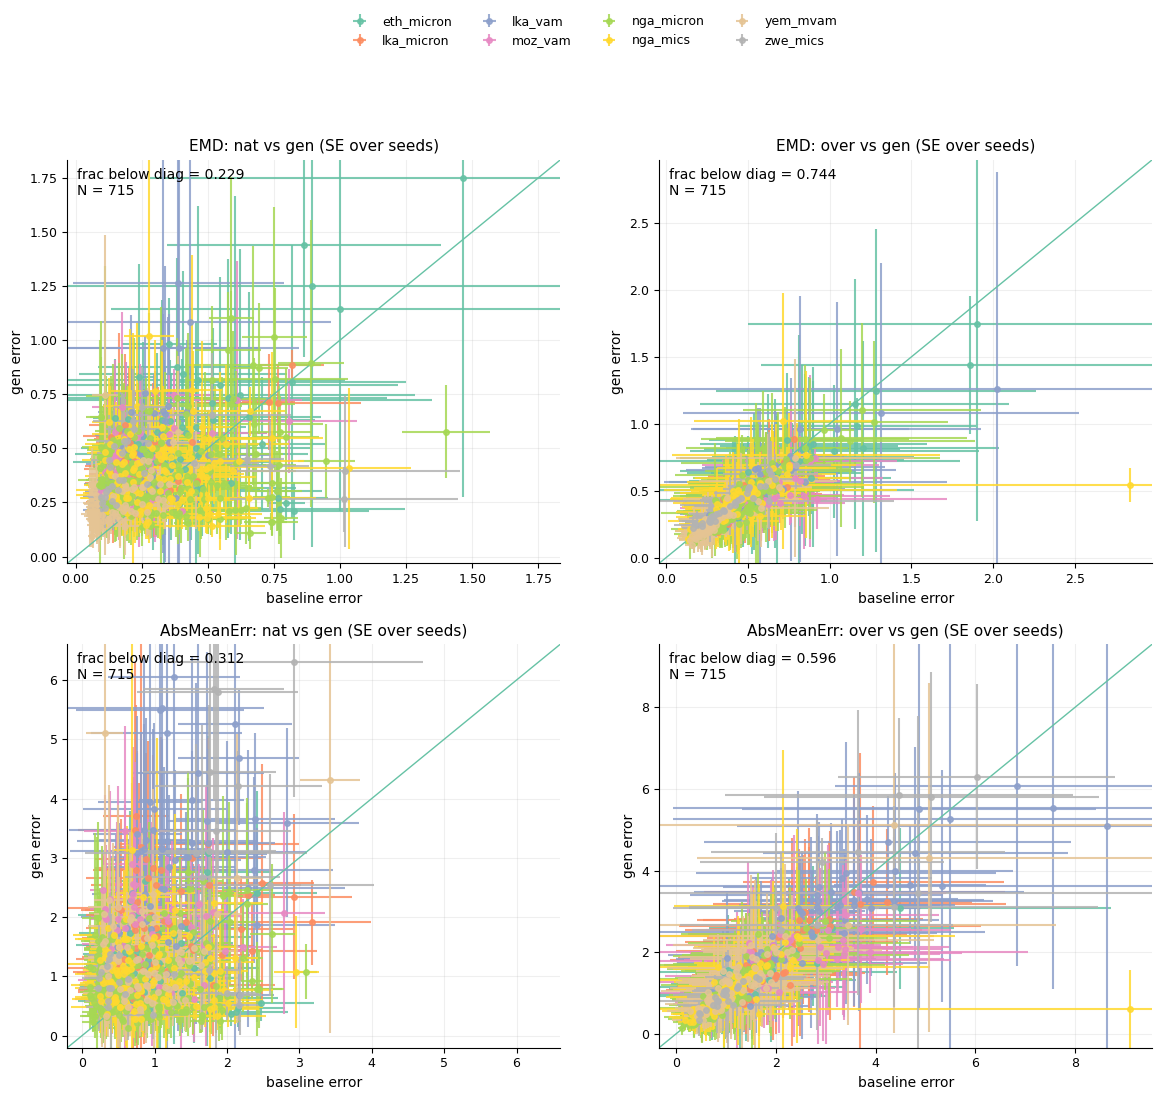

In [55]:
# plot: per-adm1-variable points, error bars = SE over seeds
import matplotlib.pyplot as plt
import numpy as np

pairs = [
    ("emd_nat_mean",  "emd_nat_se",  "emd_gen_mean",  "emd_gen_se",  "EMD: nat vs gen (SE over seeds)"),
    ("emd_over_mean", "emd_over_se", "emd_gen_mean",  "emd_gen_se",  "EMD: over vs gen (SE over seeds)"),
    ("abs_nat_mean",  "abs_nat_se",  "abs_gen_mean",  "abs_gen_se",  "AbsMeanErr: nat vs gen (SE over seeds)"),
    ("abs_over_mean", "abs_over_se", "abs_gen_mean",  "abs_gen_se",  "AbsMeanErr: over vs gen (SE over seeds)"),
]

df_plot = adm1_seed_plot.copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

exp_ids = sorted(df_plot["experiment_id"].unique())

for ax, (xmean, xse, ymean, yse, title) in zip(axes, pairs):
    # points + errorbars (colored by experiment)
    for exp_id in exp_ids:
        d = df_plot[df_plot["experiment_id"] == exp_id]
        ax.errorbar(
            d[xmean], d[ymean],
            xerr=d[xse], yerr=d[yse],
            fmt="o", linestyle="none", alpha=0.85, markersize=4,
            label=exp_id
        )

    # diagonal + bounds + fraction below
    x = df_plot[xmean].to_numpy()
    y = df_plot[ymean].to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]

    if len(x) > 0:
        lo = float(np.nanmin(np.r_[x, y]))
        hi = float(np.nanmax(np.r_[x, y]))
        pad = 0.05 * (hi - lo) if hi > lo else 1.0
        lo -= pad; hi += pad
        ax.plot([lo, hi], [lo, hi], linewidth=1)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

        frac_below = float(np.mean(y < x))
        ax.text(
            0.02, 0.98,
            f"frac below diag = {frac_below:.3f}\nN = {len(x)}",
            transform=ax.transAxes,
            va="top"
        )

    ax.set_title(title)
    ax.set_xlabel("baseline error")
    ax.set_ylabel("gen error")
    ax.grid(True, alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
fig.subplots_adjust(top=0.85)
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.98), ncol=4, frameon=False)

plt.show()

## aggregate across adm1 as well

In [56]:
# seed aggregation: just average over seeds (no seed uncertainty kept)
import numpy as np
import pandas as pd

cols_needed = [
    "experiment_id","country","dataset","train_percent_int",
    "seed","adm1_code","adm1_name","target",
    "emd_gen","emd_nat","emd_over",
    "absmeanerr_gen","absmeanerr_nat","absmeanerr_over",
]
df = metrics_all[cols_needed].copy()

group_keys = ["experiment_id","country","dataset","train_percent_int","adm1_code","adm1_name","target"]

adm1_seedmean = (
    df.groupby(group_keys, as_index=False)
      .agg(
          emd_gen_mean=("emd_gen","mean"),
          emd_nat_mean=("emd_nat","mean"),
          emd_over_mean=("emd_over","mean"),
          abs_gen_mean=("absmeanerr_gen","mean"),
          abs_nat_mean=("absmeanerr_nat","mean"),
          abs_over_mean=("absmeanerr_over","mean"),
      )
)

adm1_seedmean.head()

,experiment_id,country,dataset,train_percent_int,adm1_code,adm1_name,target,emd_gen_mean,emd_nat_mean,emd_over_mean,abs_gen_mean,abs_nat_mean,abs_over_mean
0,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,avg_adult_education,0.219636,0.774883,0.360582,0.399974,2.127490,0.688585
1,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,fe_ai,0.491232,0.230833,0.589632,1.198177,0.292243,1.260700
2,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,fol_ai,0.573629,0.308993,0.658894,1.197781,0.642937,1.367351
3,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,log_exp,0.210319,0.825422,0.266945,0.555015,2.470215,0.561714
4,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,va_ai,0.731123,0.575250,0.850176,1.193462,0.816005,1.363500


In [57]:
# aggregate across adm1: mean across adm1 + SE of that mean (SE over adm1)
import numpy as np
import pandas as pd

keys_var = ["experiment_id","country","dataset","train_percent_int","target"]

def _se_over_adm1(x: pd.Series) -> float:
    n = x.shape[0]
    if n <= 1:
        return 0.0
    return float(x.std(ddof=1)) #/ np.sqrt(n))

var_exp = (
    adm1_seedmean.groupby(keys_var, as_index=False)
    .agg(
        n_adm1=("adm1_code","nunique"),

        emd_gen_mean=("emd_gen_mean","mean"),
        emd_nat_mean=("emd_nat_mean","mean"),
        emd_over_mean=("emd_over_mean","mean"),

        abs_gen_mean=("abs_gen_mean","mean"),
        abs_nat_mean=("abs_nat_mean","mean"),
        abs_over_mean=("abs_over_mean","mean"),

        emd_gen_se=("emd_gen_mean", _se_over_adm1),
        emd_nat_se=("emd_nat_mean", _se_over_adm1),
        emd_over_se=("emd_over_mean", _se_over_adm1),

        abs_gen_se=("abs_gen_mean", _se_over_adm1),
        abs_nat_se=("abs_nat_mean", _se_over_adm1),
        abs_over_se=("abs_over_mean", _se_over_adm1),
    )
)

var_exp.head()

,experiment_id,country,dataset,train_percent_int,target,n_adm1,emd_gen_mean,emd_nat_mean,emd_over_mean,abs_gen_mean,abs_nat_mean,abs_over_mean,emd_gen_se,emd_nat_se,emd_over_se,abs_gen_se,abs_nat_se,abs_over_se
0,eth_micron,eth,micron,1,avg_adult_education,11,0.418582,0.341745,0.455713,1.142911,0.968984,1.306606,0.124762,0.182390,0.124190,0.373864,0.493875,0.426445
1,eth_micron,eth,micron,1,fe_ai,11,0.469305,0.367028,0.518684,1.037533,0.857837,1.071538,0.146836,0.217723,0.130520,0.387434,0.600894,0.366191
2,eth_micron,eth,micron,1,fol_ai,11,0.572827,0.467211,0.648392,1.124815,0.987986,1.355824,0.317311,0.232712,0.426452,0.709136,0.487059,1.072658
3,eth_micron,eth,micron,1,log_exp,11,0.454494,0.348894,0.494821,1.180774,0.974722,1.257415,0.165243,0.173999,0.170412,0.502191,0.537849,0.505419
4,eth_micron,eth,micron,1,va_ai,11,0.758526,0.610436,0.821233,1.191008,0.982126,1.293754,0.408241,0.335579,0.439650,0.602010,0.559903,0.677257


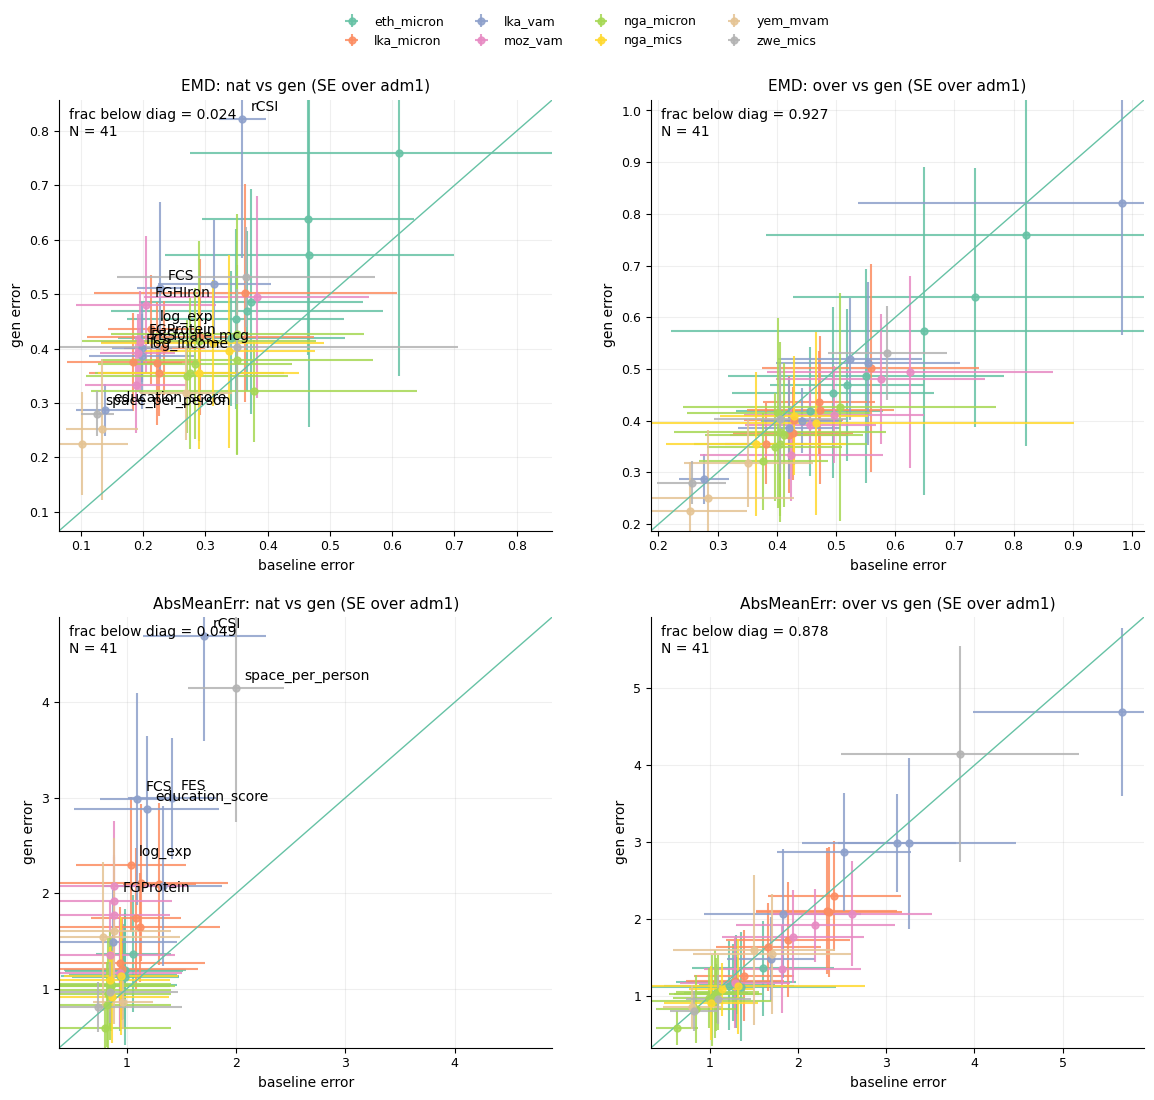

In [58]:
# plot + label points far above diagonal (y - yerr > x + xerr)
import matplotlib.pyplot as plt
import numpy as np

pairs = [
    ("emd_nat_mean",  "emd_nat_se",  "emd_gen_mean",  "emd_gen_se",  "EMD: nat vs gen (SE over adm1)"),
    ("emd_over_mean", "emd_over_se", "emd_gen_mean",  "emd_gen_se",  "EMD: over vs gen (SE over adm1)"),
    ("abs_nat_mean",  "abs_nat_se",  "abs_gen_mean",  "abs_gen_se",  "AbsMeanErr: nat vs gen (SE over adm1)"),
    ("abs_over_mean", "abs_over_se", "abs_gen_mean",  "abs_gen_se",  "AbsMeanErr: over vs gen (SE over adm1)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

exp_ids = sorted(var_exp["experiment_id"].unique())

for ax, (xmean, xse, ymean, yse, title) in zip(axes, pairs):
    # points + errorbars (colored by experiment)
    for exp_id in exp_ids:
        d = var_exp[var_exp["experiment_id"] == exp_id]
        ax.errorbar(
            d[xmean], d[ymean],
            xerr=d[xse], yerr=d[yse],
            fmt="o", linestyle="none", alpha=0.85, markersize=5,
            label=exp_id
        )

    # diagonal and bounds
    x = var_exp[xmean].to_numpy()
    y = var_exp[ymean].to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]

    if len(x) > 0:
        lo = float(np.nanmin(np.r_[x, y]))
        hi = float(np.nanmax(np.r_[x, y]))
        pad = 0.05 * (hi - lo) if hi > lo else 1.0
        lo -= pad; hi += pad
        ax.plot([lo, hi], [lo, hi], linewidth=1)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

        frac_below = float(np.mean(y < x))
        ax.text(
            0.02, 0.98,
            f"frac below diag = {frac_below:.3f}\nN = {len(x)}",
            transform=ax.transAxes,
            va="top"
        )

    # label points clearly above diagonal (no bar intersection)
    tmp = var_exp[[ "experiment_id", "target", xmean, xse, ymean, yse ]].replace([np.inf, -np.inf], np.nan)
    tmp = tmp.dropna(subset=[xmean, ymean])

    mask = (tmp[ymean] - tmp[yse]) > (tmp[xmean] + tmp[xse])
    out = tmp[mask].copy()

    for _, r in out.iterrows():
        ax.annotate(
            str(r["target"]),
            (r[xmean], r[ymean]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=10
        )

    ax.set_title(title)
    ax.set_xlabel("baseline error")
    ax.set_ylabel("gen error")
    ax.grid(True, alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
fig.subplots_adjust(top=0.9)
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.98), ncol=4, frameon=False)

plt.show()

In [59]:
import matplotlib.pyplot as plt
from cycler import cycler
import numpy as np

cmap = plt.get_cmap('Set2')
n_colors = 8  # quante linee vuoi distinguere
colors = [cmap(i / (n_colors - 1)) for i in range(n_colors)]

plt.rcParams['axes.prop_cycle'] = cycler('color', colors)

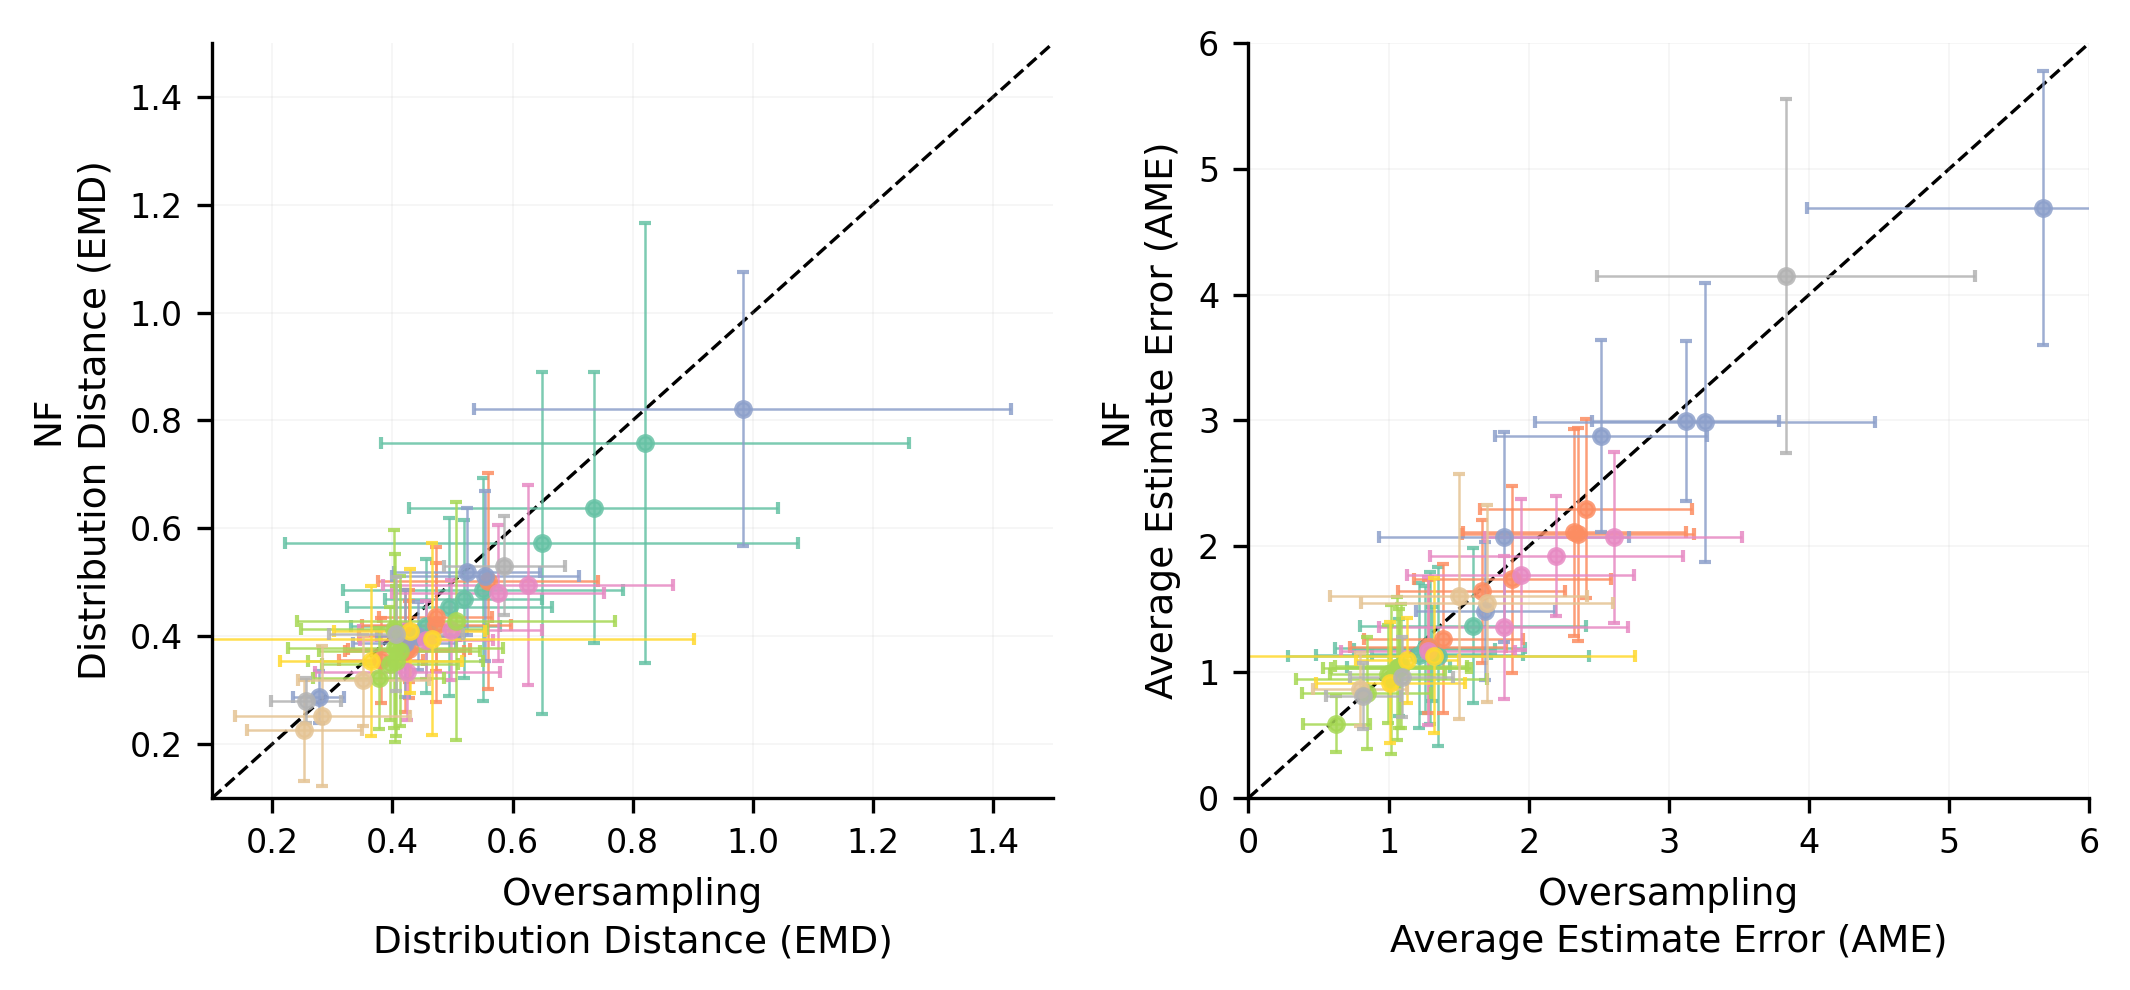

In [61]:
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

pairs = [
    ("emd_nat_mean",  "emd_nat_se",  "emd_gen_mean",  "emd_gen_se",  "EMD: nat vs gen (SE over adm1)"),
    ("emd_over_mean", "emd_over_se", "emd_gen_mean",  "emd_gen_se",  "EMD: over vs gen (SE over adm1)"),
    ("abs_nat_mean",  "abs_nat_se",  "abs_gen_mean",  "abs_gen_se",  "AbsMeanErr: nat vs gen (SE over adm1)"),
    ("abs_over_mean", "abs_over_se", "abs_gen_mean",  "abs_gen_se",  "AbsMeanErr: over vs gen (SE over adm1)"),
]
pairs_right = [pairs[1], pairs[3]]

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.prop_cycle": cycler("color", plt.get_cmap("Set2").colors),
})

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.4), dpi=300)
axes = np.atleast_1d(axes)

exp_ids = sorted(var_exp["experiment_id"].unique())

xlabels = [
    "Oversampling\nDistribution Distance (EMD)",
    "Oversampling\nAverage Estimate Error (AME)",
]
ylabels = [
    "NF\nDistribution Distance (EMD)",
    "NF\nAverage Estimate Error (AME)",
]
xlims = [(0.1, 1.5), (0, 6)]
ylims = [(0.1, 1.5), (0, 6)]

for ax, (xmean, xse, ymean, yse, _), xlim, ylim, xlab, ylab in zip(
    axes, pairs_right, xlims, ylims, xlabels, ylabels
):
    lo, hi = xlim
    ax.set_xlim(lo, hi)
    ax.set_ylim(*ylim)
    ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=0.8, zorder=1)

    for exp_id in exp_ids:
        d = var_exp[var_exp["experiment_id"] == exp_id]
        ax.errorbar(
            d[xmean], d[ymean],
            xerr=d[xse], yerr=d[yse],
            fmt="o", linestyle="none",
            markersize=3.5,
            alpha=0.85,
            elinewidth=0.6,
            capsize=1.5,
            zorder=2,
            label=exp_id,
        )

    ax.set_title("")
    ax.set_xlabel(xlab, linespacing=1.4)
    ax.set_ylabel(ylab, linespacing=1.4)
    ax.grid(True, alpha=0.12, linewidth=0.4)

# legend in the upper-left triangle of the right panel (above the diagonal)
handles, labels = axes[1].get_legend_handles_labels()
#axes[1].legend(
#    handles, labels,
#    loc="upper left",
#    bbox_to_anchor=(0.03, 0.97),
#    ncol=1,
#    frameon=True,
#    framealpha=0.92,
#    edgecolor="0.82",
#    fancybox=False,
#    fontsize=7,
#    handlelength=1.0,
#    handletextpad=0.25,
#    labelspacing=0.32,
#    borderpad=0.4,
#    markerscale=0.8,
#)

fig.tight_layout(pad=1.2)
plt.show()

with std dev instead of std error

In [40]:
# aggregate across adm1: mean across adm1 + SD over adm1 (SD across adm1)
import numpy as np
import pandas as pd

keys_var = ["experiment_id","country","dataset","train_percent_int","target"]

def _sd_over_adm1(x: pd.Series) -> float:
    n = x.shape[0]
    if n <= 1:
        return 0.0
    return float(x.std(ddof=1))

var_exp_sd = (
    adm1_seedmean.groupby(keys_var, as_index=False)
    .agg(
        n_adm1=("adm1_code","nunique"),

        emd_gen_mean=("emd_gen_mean","mean"),
        emd_nat_mean=("emd_nat_mean","mean"),
        emd_over_mean=("emd_over_mean","mean"),

        abs_gen_mean=("abs_gen_mean","mean"),
        abs_nat_mean=("abs_nat_mean","mean"),
        abs_over_mean=("abs_over_mean","mean"),

        emd_gen_sd=("emd_gen_mean", _sd_over_adm1),
        emd_nat_sd=("emd_nat_mean", _sd_over_adm1),
        emd_over_sd=("emd_over_mean", _sd_over_adm1),

        abs_gen_sd=("abs_gen_mean", _sd_over_adm1),
        abs_nat_sd=("abs_nat_mean", _sd_over_adm1),
        abs_over_sd=("abs_over_mean", _sd_over_adm1),
    )
)

var_exp_sd.head()

,experiment_id,country,dataset,train_percent_int,target,n_adm1,emd_gen_mean,emd_nat_mean,emd_over_mean,abs_gen_mean,abs_nat_mean,abs_over_mean,emd_gen_sd,emd_nat_sd,emd_over_sd,abs_gen_sd,abs_nat_sd,abs_over_sd
0,eth_micron,eth,micron,1,avg_adult_education,11,0.418582,0.341745,0.455713,1.142911,0.968984,1.306606,0.124762,0.182390,0.124190,0.373864,0.493875,0.426445
1,eth_micron,eth,micron,1,fe_ai,11,0.469305,0.367028,0.518684,1.037533,0.857837,1.071538,0.146836,0.217723,0.130520,0.387434,0.600894,0.366191
2,eth_micron,eth,micron,1,fol_ai,11,0.572827,0.467211,0.648392,1.124815,0.987986,1.355824,0.317311,0.232712,0.426452,0.709136,0.487059,1.072658
3,eth_micron,eth,micron,1,log_exp,11,0.454494,0.348894,0.494821,1.180774,0.974722,1.257415,0.165243,0.173999,0.170412,0.502191,0.537849,0.505419
4,eth_micron,eth,micron,1,va_ai,11,0.758526,0.610436,0.821233,1.191008,0.982126,1.293754,0.408241,0.335579,0.439650,0.602010,0.559903,0.677257


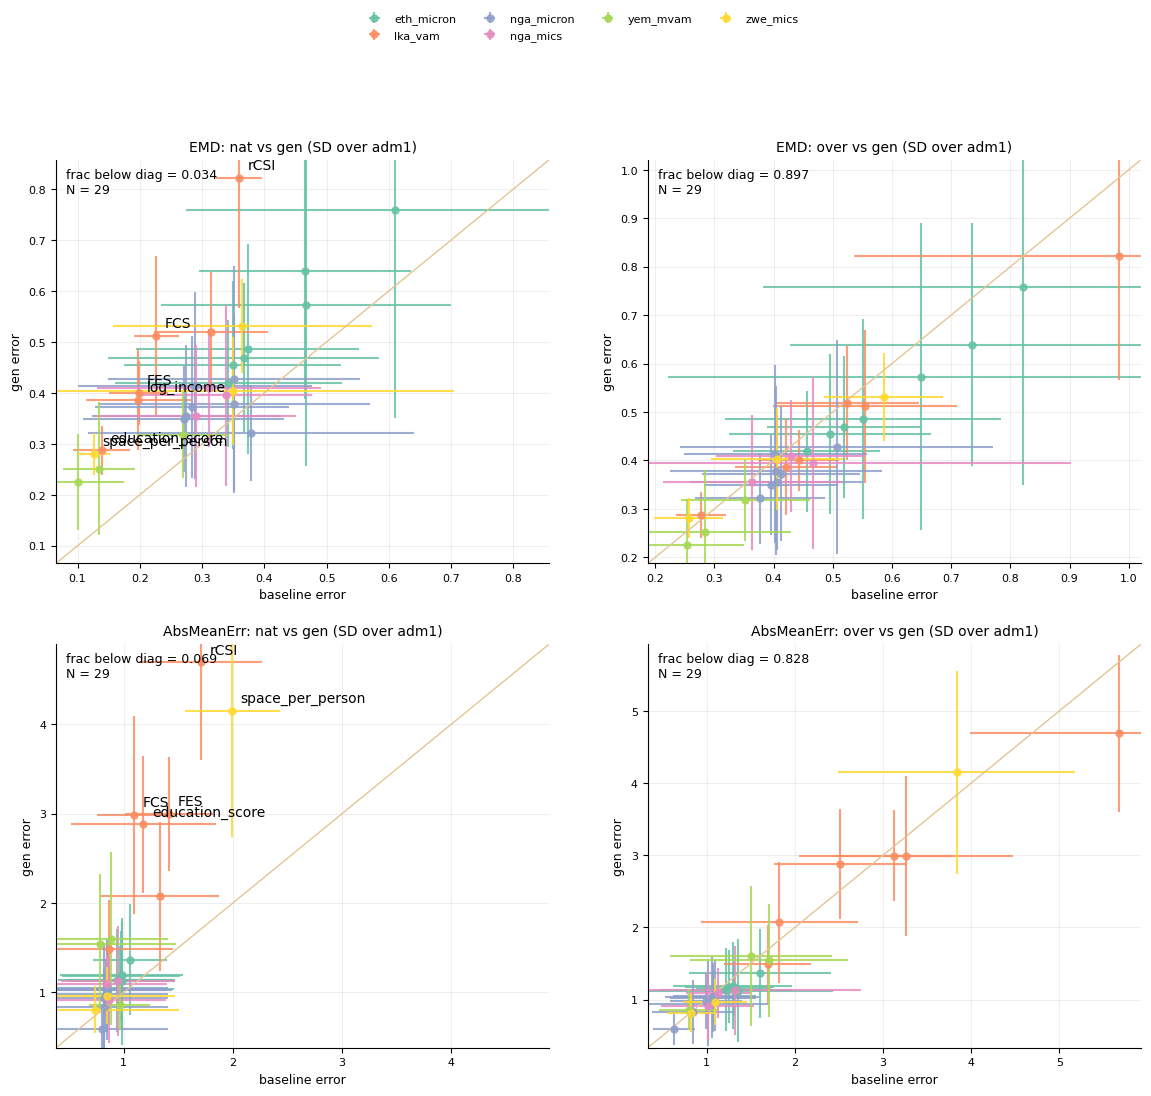

In [41]:
# plot + label points clearly above diagonal using SD bars over adm1
import matplotlib.pyplot as plt
import numpy as np

pairs = [
    ("emd_nat_mean",  "emd_nat_sd",  "emd_gen_mean",  "emd_gen_sd",  "EMD: nat vs gen (SD over adm1)"),
    ("emd_over_mean", "emd_over_sd", "emd_gen_mean",  "emd_gen_sd",  "EMD: over vs gen (SD over adm1)"),
    ("abs_nat_mean",  "abs_nat_sd",  "abs_gen_mean",  "abs_gen_sd",  "AbsMeanErr: nat vs gen (SD over adm1)"),
    ("abs_over_mean", "abs_over_sd", "abs_gen_mean",  "abs_gen_sd",  "AbsMeanErr: over vs gen (SD over adm1)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

exp_ids = sorted(var_exp_sd["experiment_id"].unique())

for ax, (xmean, xsd, ymean, ysd, title) in zip(axes, pairs):
    # points + errorbars (colored by experiment)
    for exp_id in exp_ids:
        d = var_exp_sd[var_exp_sd["experiment_id"] == exp_id]
        ax.errorbar(
            d[xmean], d[ymean],
            xerr=d[xsd], yerr=d[ysd],
            fmt="o", linestyle="none", alpha=0.85, markersize=5,
            label=exp_id
        )

    # diagonal + bounds + fraction below
    x = var_exp_sd[xmean].to_numpy()
    y = var_exp_sd[ymean].to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]

    if len(x) > 0:
        lo = float(np.nanmin(np.r_[x, y]))
        hi = float(np.nanmax(np.r_[x, y]))
        pad = 0.05 * (hi - lo) if hi > lo else 1.0
        lo -= pad; hi += pad
        ax.plot([lo, hi], [lo, hi], linewidth=1)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

        frac_below = float(np.mean(y < x))
        ax.text(
            0.02, 0.98,
            f"frac below diag = {frac_below:.3f}\nN = {len(x)}",
            transform=ax.transAxes,
            va="top"
        )

    # label points clearly above diagonal (no bar intersection)
    tmp = var_exp_sd[[ "experiment_id", "target", xmean, xsd, ymean, ysd ]].replace([np.inf, -np.inf], np.nan)
    tmp = tmp.dropna(subset=[xmean, ymean])

    mask = (tmp[ymean] - tmp[ysd]) > (tmp[xmean] + tmp[xsd])
    out = tmp[mask].copy()

    for _, r in out.iterrows():
        ax.annotate(
            str(r["target"]),
            (r[xmean], r[ymean]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=10
        )

    ax.set_title(title)
    ax.set_xlabel("baseline error")
    ax.set_ylabel("gen error")
    ax.grid(True, alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
fig.subplots_adjust(top=0.85)
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.98), ncol=4, frameon=False)

plt.show()

## Maps visualization

In [42]:
# prep geodata + improvement table (avg over seeds already done at adm1 level)
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely import wkt

# 1) merge geometry back at adm1 level
g = geom_lookup[["experiment_id","adm1_code","adm1geometry"]].drop_duplicates(["experiment_id","adm1_code"]).copy()

adm1_seedmean_geo = (
    adm1_seedmean
    .merge(g, on=["experiment_id","adm1_code"], how="left")
)

adm1_seedmean_geo["geometry"] = adm1_seedmean_geo["adm1geometry"].apply(lambda s: wkt.loads(s) if isinstance(s, str) and len(s) else None)
gdf = gpd.GeoDataFrame(adm1_seedmean_geo.drop(columns=["adm1geometry"]), geometry="geometry", crs="EPSG:4326")

# 2) improvements (baseline - gen)
gdf["imp_emd_nat"]  = gdf["emd_nat_mean"]  - gdf["emd_gen_mean"]
gdf["imp_emd_over"] = gdf["emd_over_mean"] - gdf["emd_gen_mean"]
gdf["imp_abs_nat"]  = gdf["abs_nat_mean"]  - gdf["abs_gen_mean"]
gdf["imp_abs_over"] = gdf["abs_over_mean"] - gdf["abs_gen_mean"]

# layout sets
exp_ids = sorted(gdf["experiment_id"].unique().tolist())
targets_all = sorted(gdf["target"].unique().tolist())

len(exp_ids), len(targets_all)

(6, 15)

In [43]:
# experiment colors (reuse your scatter color_map if you already have one)
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

cmap = plt.get_cmap("tab10")
exp_color_map = {exp: cmap(i % 10) for i, exp in enumerate(exp_ids)}

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.patches import Rectangle
from matplotlib.transforms import Bbox

cmap_rwg = LinearSegmentedColormap.from_list("rwg", ["#d7191c", "#ffffff", "#1a9641"])

targets_by_exp = {
    exp: sorted(gdf.loc[gdf["experiment_id"] == exp, "target"].dropna().unique().tolist())
    for exp in exp_ids
}

def plot_improvement(
    gdf,
    value_col,
    fig_title,
    vlim_percentile=98,
    box_lw=3.0,
    title_fs=22,
    exp_fs=22,     # big like before
    var_fs=15,
    header_h=0.28,
    row_hspace=0.08,   # << less space between boxes
    col_wspace=0.12,
    title_band=0.25,
    cb_band=0.20,      # << smaller cb area

    # sizing similar to your original
    map_w=3.3,
    row_h=4.2,

    # fixed label column width (relative to a map col)
    label_col_w=0.42,

    # colorbar shorter + thinner (x,y,w,h inside cb band axis)
    cb_inset = (0.38, 0.54, 0.26, 0.25),
):
    vals = gdf[value_col].replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    if vals.size == 0:
        print(f"no data for {value_col}")
        return

    vmax = float(np.nanpercentile(np.abs(vals), vlim_percentile))
    if vmax == 0:
        vmax = float(np.nanmax(np.abs(vals))) if float(np.nanmax(np.abs(vals))) > 0 else 1.0
    norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)

    n_exp = len(exp_ids)
    max_cols = max(len(targets_by_exp[e]) for e in exp_ids)

    fig = plt.figure(figsize=(map_w * (max_cols + label_col_w), row_h * n_exp))

    outer = GridSpec(
        nrows=n_exp + 2, ncols=1, figure=fig,
        height_ratios=[title_band] + [1.0] * n_exp + [cb_band],
        hspace=row_hspace
    )

    # --- title band ---
    ax_title = fig.add_subplot(outer[0, 0])
    ax_title.axis("off")
    ax_title.text(
        0.5, 0.55, str(fig_title).upper(),
        ha="center", va="center",
        fontsize=title_fs, fontweight="bold"
    )

    # --- experiment rows ---
    for i, exp_id in enumerate(exp_ids, start=1):
        tgts = targets_by_exp[exp_id]
        ncols = len(tgts)
        box_color = exp_color_map.get(exp_id, "black")

        # FIXED grid per row: 2 rows, (1 label col + max_cols map cols)
        inner = GridSpecFromSubplotSpec(
            nrows=2, ncols=max_cols + 1,
            subplot_spec=outer[i, 0],
            height_ratios=[header_h, 1.0],
            width_ratios=[label_col_w] + [1.0] * max_cols,
            wspace=col_wspace,
            hspace=0.0
        )

        row_axes = []

        # label axis spanning both rows (vertical, colored, large)
        ax_lab = fig.add_subplot(inner[:, 0])
        ax_lab.axis("off")
        ax_lab.text(
            0.10, 0.5, exp_id,
            rotation=90,
            ha="left", va="center",
            fontsize=exp_fs, fontweight="bold",
            color=box_color,
            transform=ax_lab.transAxes
        )
        row_axes.append(ax_lab)

        # headers and maps for existing targets; blanks for the rest to keep alignment
        for j in range(max_cols):
            col = j + 1

            # header
            ax_h = fig.add_subplot(inner[0, col])
            ax_h.axis("off")
            if j < ncols:
                ax_h.text(0.5, 0.7, str(tgts[j]), ha="center", va="center", fontsize=var_fs)
            row_axes.append(ax_h)

            # map
            ax_m = fig.add_subplot(inner[1, col])
            ax_m.set_axis_off()
            row_axes.append(ax_m)

            if j >= ncols:
                continue

            tgt = tgts[j]
            sub = gdf[(gdf["experiment_id"] == exp_id) & (gdf["target"] == tgt)]
            if sub.empty or sub["geometry"].isna().all():
                continue

            sub.plot(
                column=value_col,
                ax=ax_m,
                cmap=cmap_rwg,
                norm=norm,
                linewidth=0.25,
                edgecolor="white",
                legend=False,
            )

        # border around the whole row (no awkward overlay)
        bbox = Bbox.union([ax.get_position() for ax in row_axes])
        fig.add_artist(
            Rectangle(
                (bbox.x0, bbox.y0), bbox.width, bbox.height,
                transform=fig.transFigure,
                fill=False, edgecolor=box_color, linewidth=box_lw
            )
        )

    # --- colorbar band (shorter + thinner) ---
    ax_cb = fig.add_subplot(outer[-1, 0])
    ax_cb.axis("off")

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_rwg)
    sm.set_array([])

    cb_ax = ax_cb.inset_axes(list(cb_inset))
    cb = fig.colorbar(sm, cax=cb_ax, orientation="horizontal")
    cb.set_label("BASELINE - GEN", fontsize=15)
    cb.ax.tick_params(labelsize=9)

    plt.show()

In [45]:
gdf.columns

Index(['experiment_id', 'country', 'dataset', 'train_percent_int', 'adm1_code',
       'adm1_name', 'target', 'emd_gen_mean', 'emd_nat_mean', 'emd_over_mean',
       'abs_gen_mean', 'abs_nat_mean', 'abs_over_mean', 'geometry',
       'imp_emd_nat', 'imp_emd_over', 'imp_abs_nat', 'imp_abs_over'],
      dtype='object')

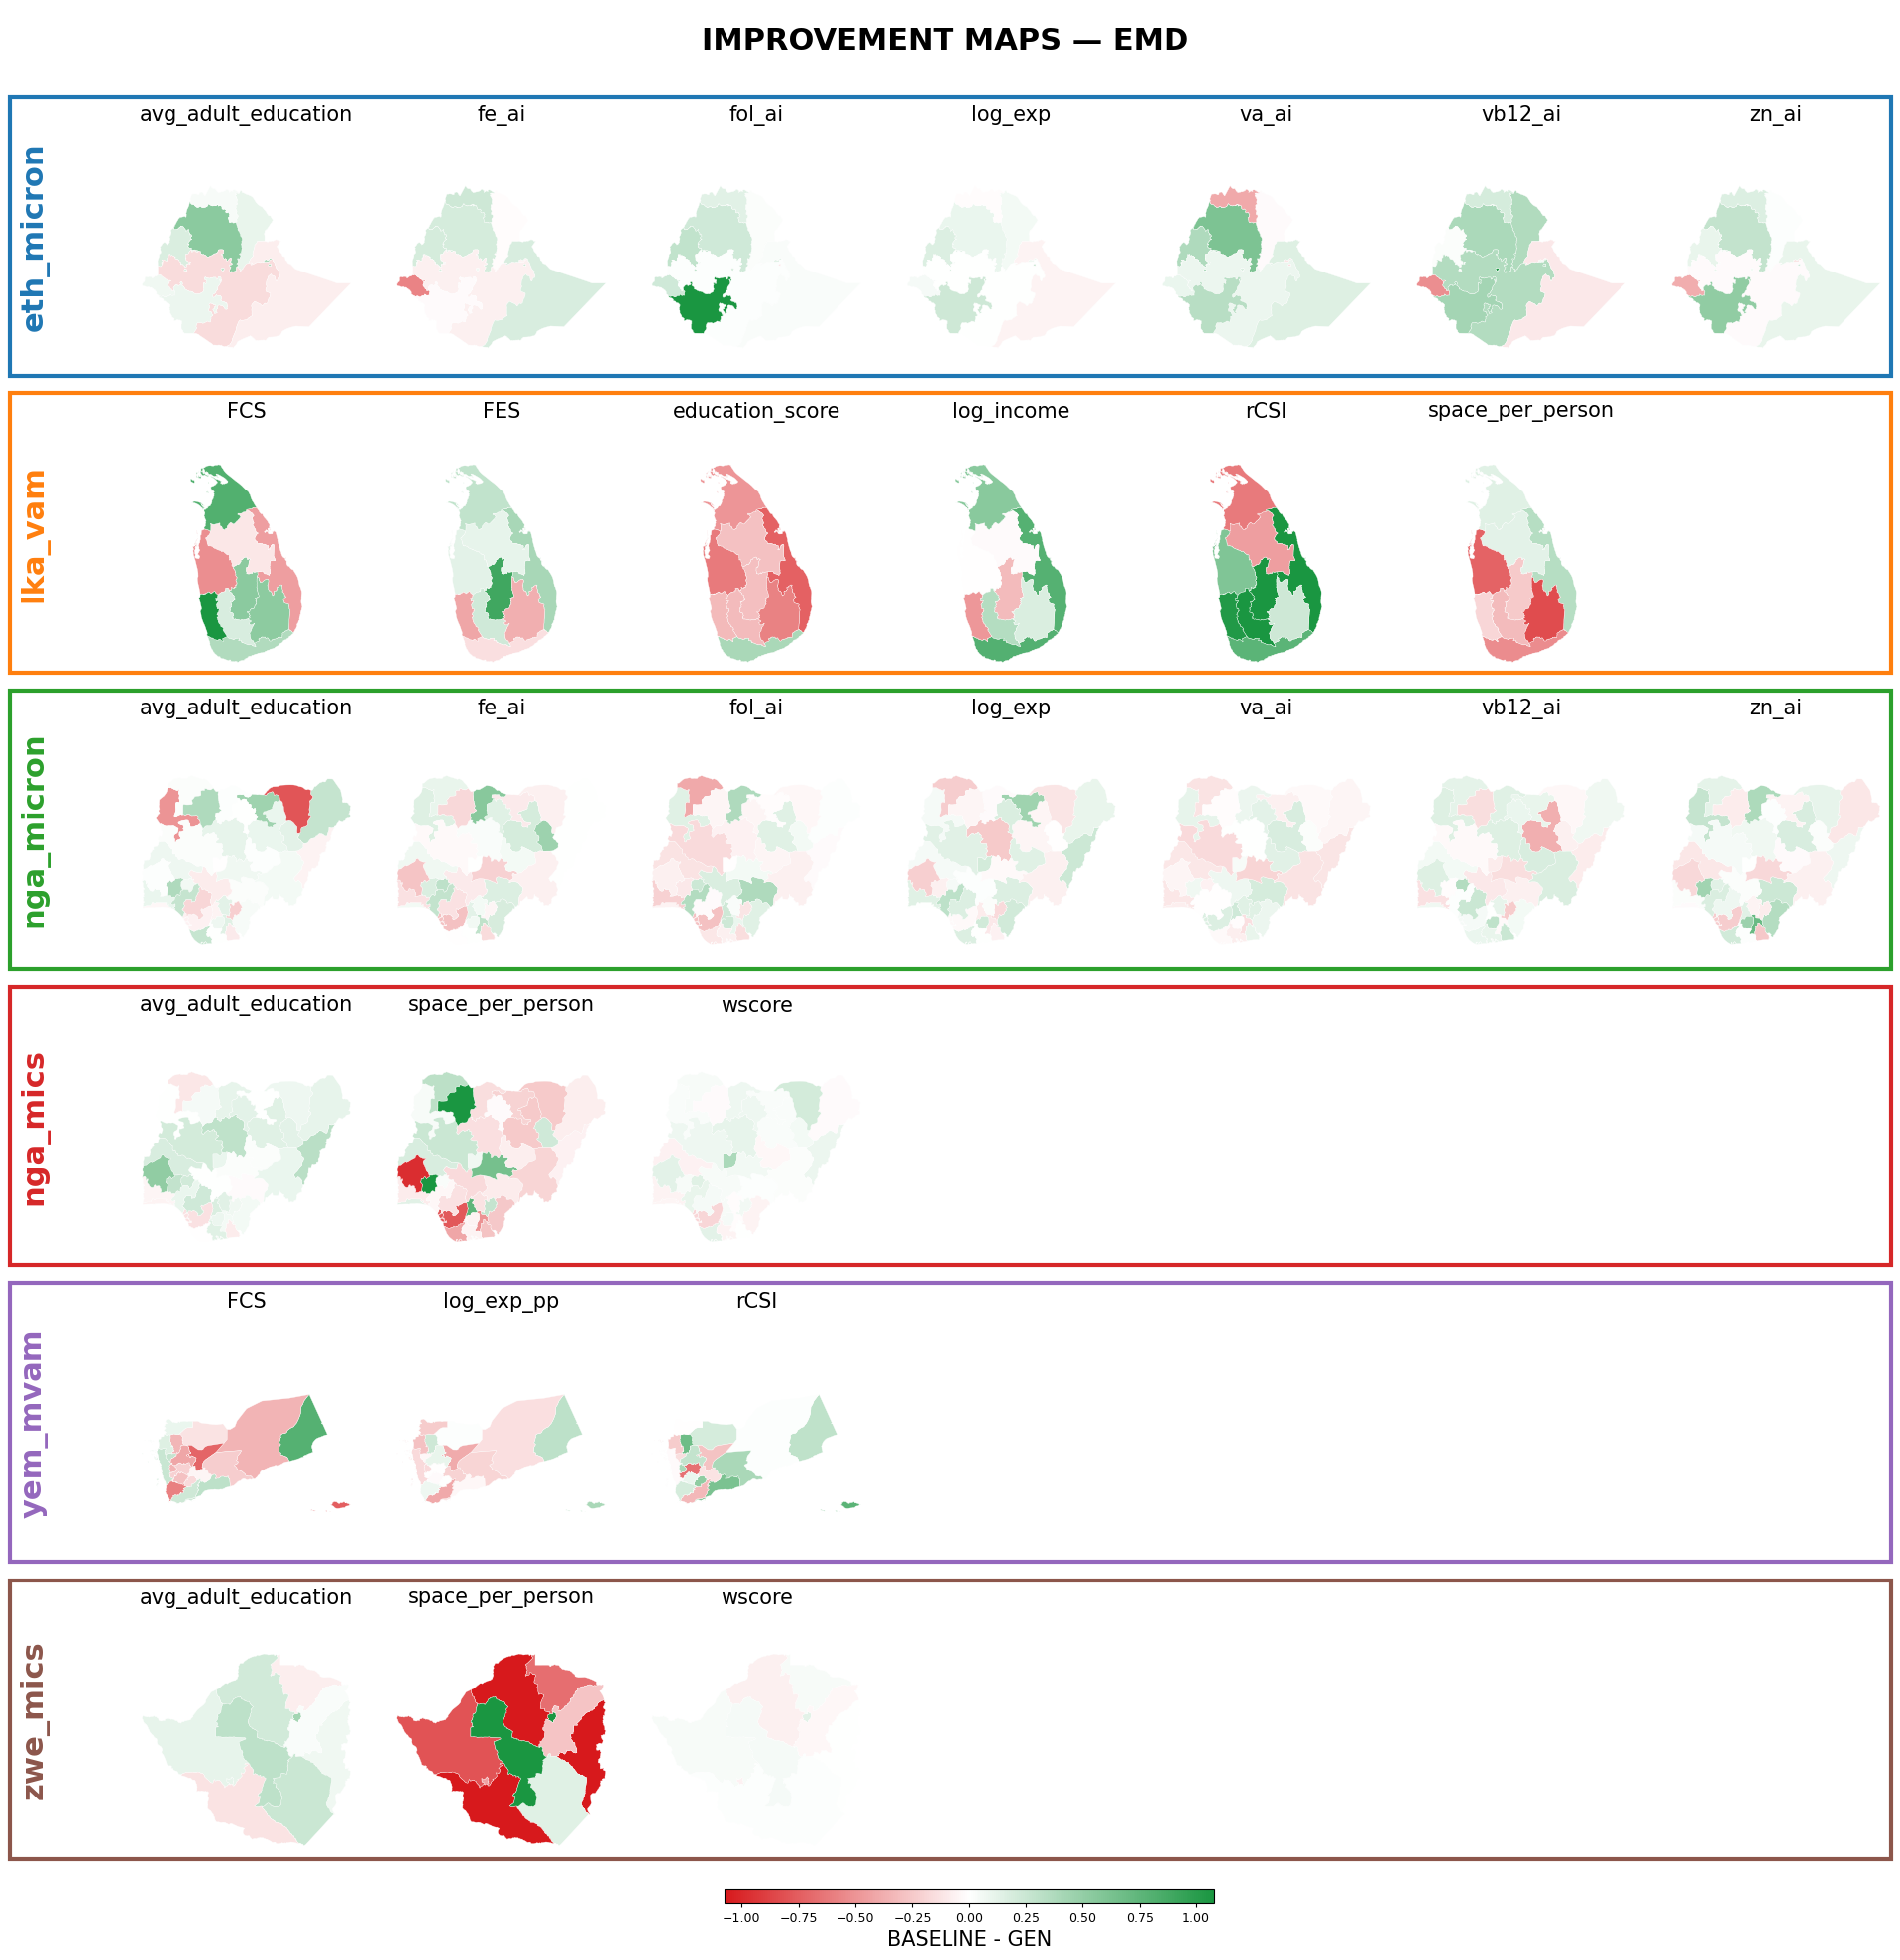

In [46]:
plot_improvement(gdf, "imp_abs_over", "Improvement maps — EMD ")


## Improvement with intrinsic variability

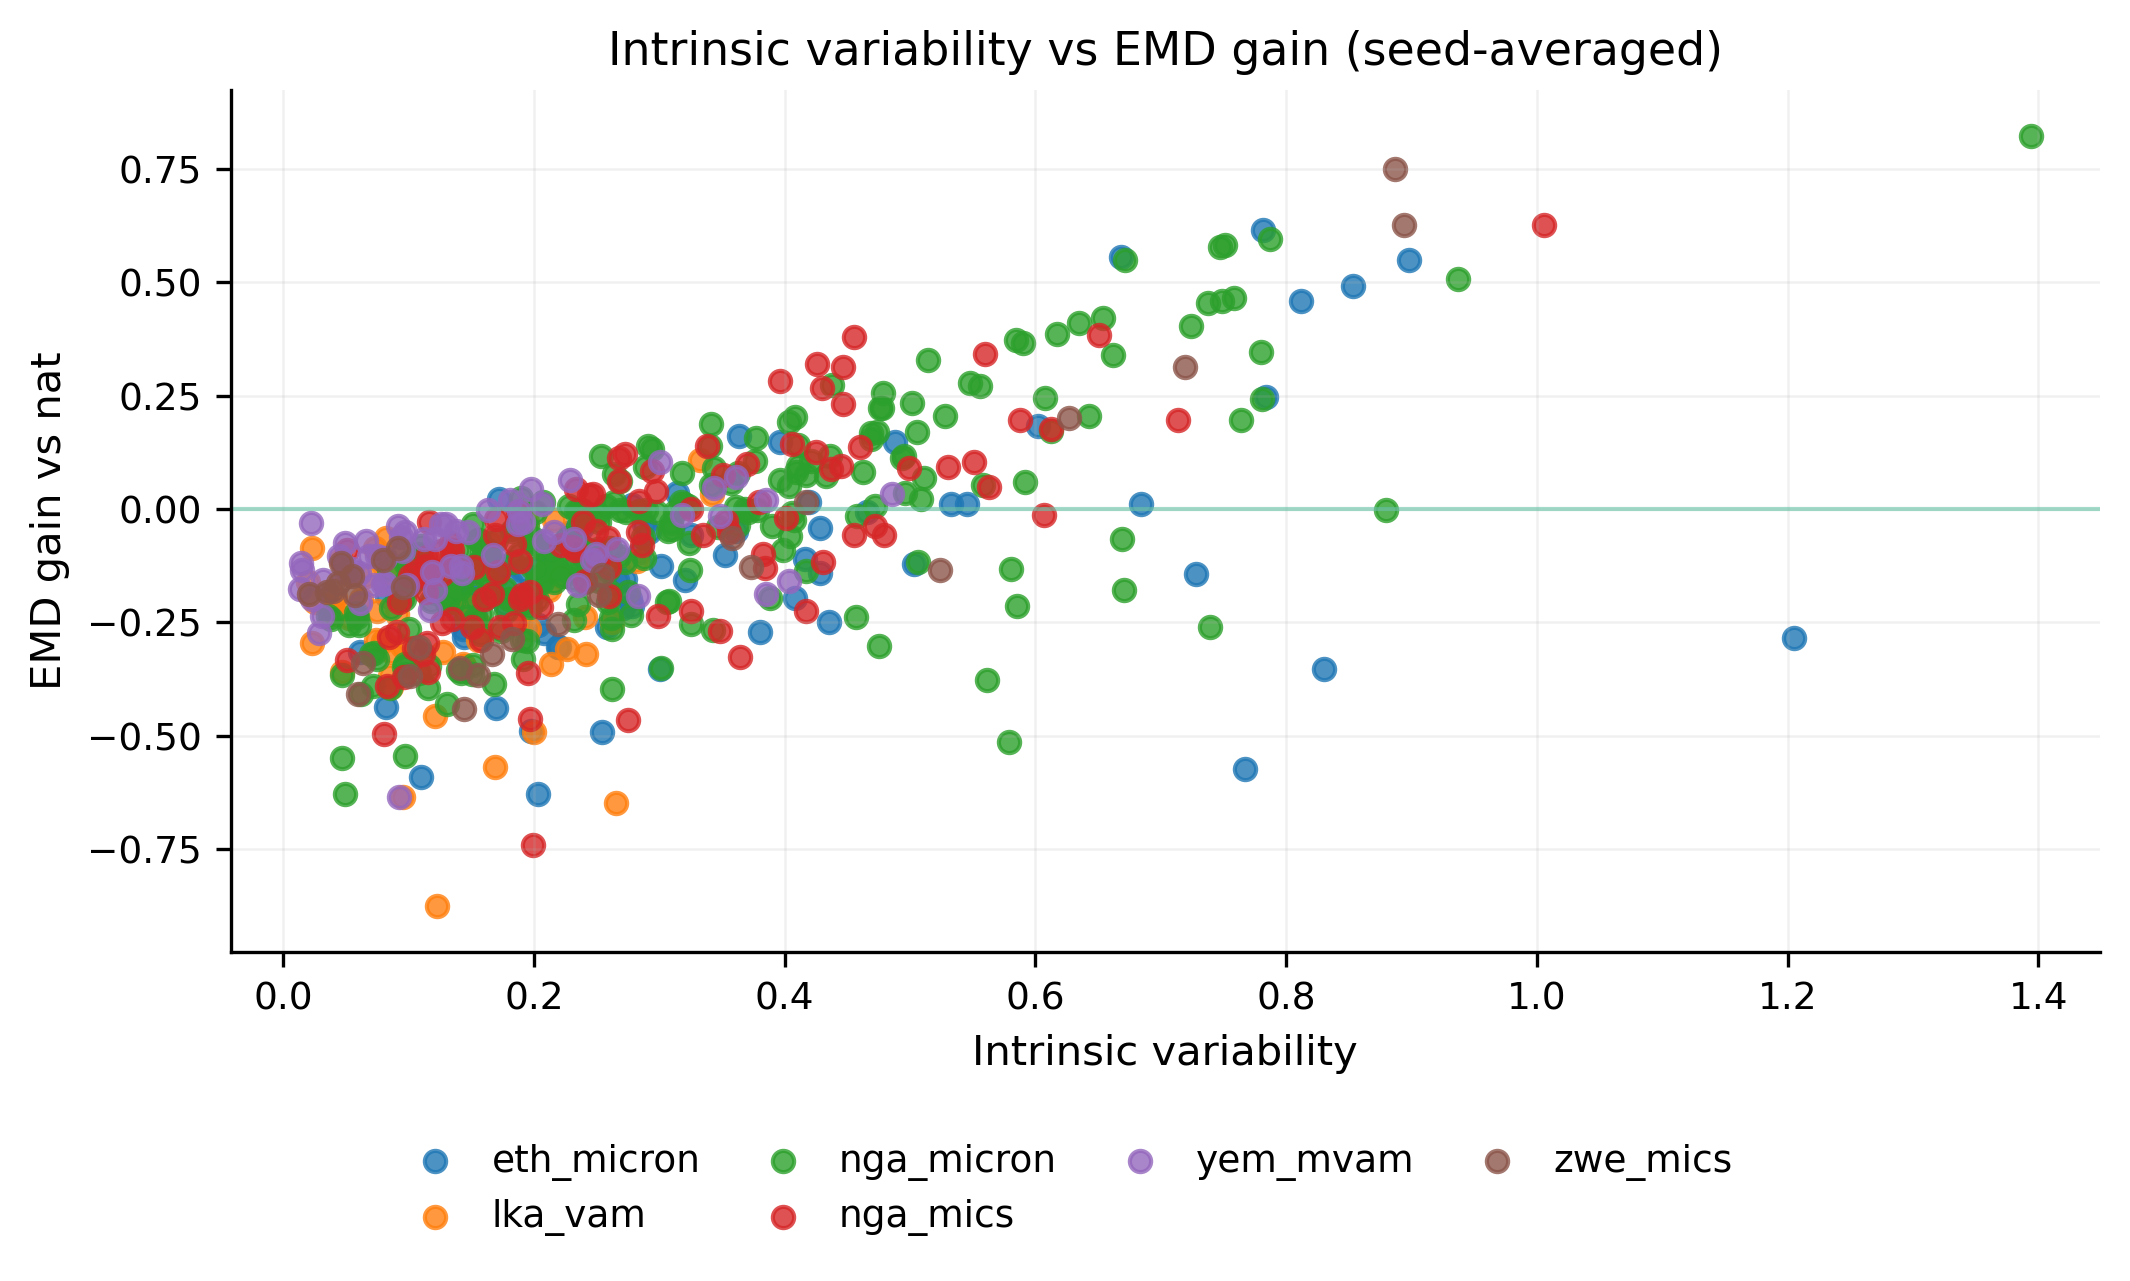

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "/data/shared/fsibilla/clean_code/Q1/across_experiments_eval_minimal/metrics_all_experiments_minimal.csv"
df = pd.read_csv(csv_path)

# numeric
for c in ["variability_intrinsic", "emd_gen", "emd_nat"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# clean
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["experiment_id", "adm1_code", "target",
                                                          "variability_intrinsic", "emd_gen", "emd_nat"]).copy()

# 1) average over seeds first (per experiment x adm1 x target)
grp_cols = ["experiment_id", "adm1_code", "target"]
m = (
    df.groupby(grp_cols, as_index=False)
      .agg(
          variability_intrinsic=("variability_intrinsic", "mean"),
          emd_gen=("emd_gen", "mean"),
          emd_nat=("emd_nat", "mean"),
      )
)

# 2) improvement vs national baseline AFTER seed-mean
m["emd_gain_vs_nat"] = m["emd_nat"] - m["emd_gen"]

# ---- style ----
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

exp_ids = sorted(m["experiment_id"].unique())

# same colors as before
if "exp_color_map" in globals():
    color_map = {e: exp_color_map.get(e, None) for e in exp_ids}
else:
    cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    color_map = {e: cycle[i % len(cycle)] for i, e in enumerate(exp_ids)} if cycle else {e: None for e in exp_ids}

fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=300)

for exp_id in exp_ids:
    sub = m[m["experiment_id"] == exp_id]
    ax.scatter(
        sub["variability_intrinsic"],
        sub["emd_gain_vs_nat"],
        s=26,
        alpha=0.80,
        color=color_map.get(exp_id, None),
        label=exp_id
    )

ax.axhline(0, linewidth=1.0, alpha=0.6)

ax.set_xlabel("Intrinsic variability")
ax.set_ylabel("EMD gain vs nat")
ax.set_title("Intrinsic variability vs EMD gain (seed-averaged)")

ax.grid(True, alpha=0.18, linewidth=0.6)

# limits with padding
x = m["variability_intrinsic"].to_numpy()
y = m["emd_gain_vs_nat"].to_numpy()
xm = np.isfinite(x); ym = np.isfinite(y)
if xm.any():
    xlo, xhi = np.nanmin(x[xm]), np.nanmax(x[xm])
    xpad = 0.04 * (xhi - xlo) if xhi > xlo else 0.1
    ax.set_xlim(xlo - xpad, xhi + xpad)
if ym.any():
    ylo, yhi = np.nanmin(y[ym]), np.nanmax(y[ym])
    ypad = 0.06 * (yhi - ylo) if yhi > ylo else 0.1
    ax.set_ylim(ylo - ypad, yhi + ypad)

# legend outside
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=min(4, len(exp_ids)),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.5
)
fig.tight_layout(rect=[0, 0.10, 1, 1])

plt.show()

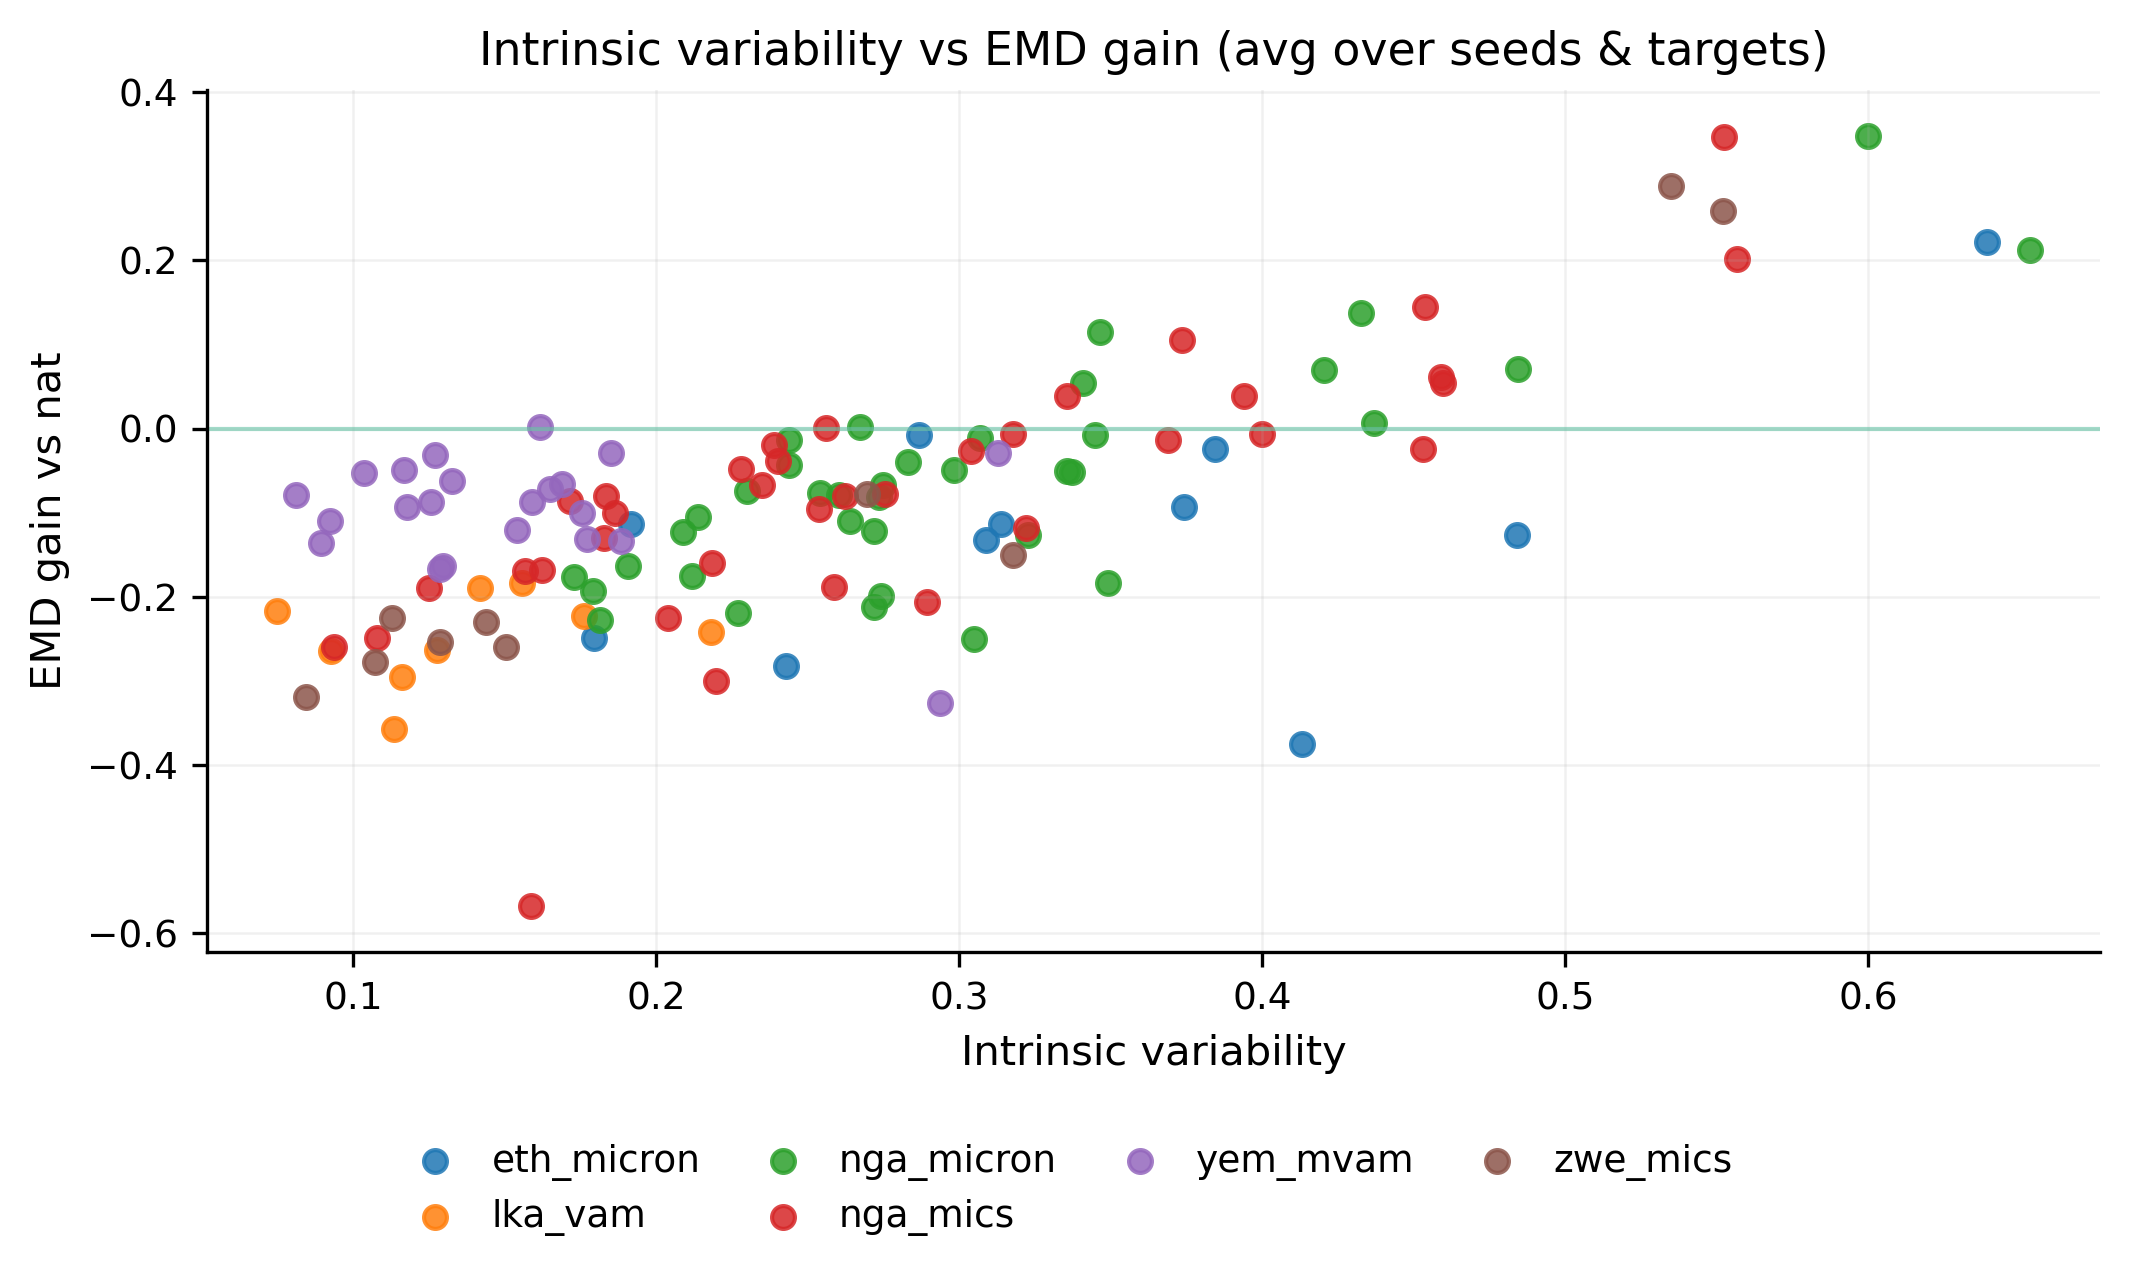

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "/data/shared/fsibilla/clean_code/Q1/across_experiments_eval_minimal/metrics_all_experiments_minimal.csv"
df = pd.read_csv(csv_path)

# numeric
for c in ["variability_intrinsic", "emd_gen", "emd_nat"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# clean
df = df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["experiment_id", "adm1_code", "target", "variability_intrinsic", "emd_gen", "emd_nat"]
).copy()

# 1) average over seeds first: (experiment, adm1, target)
g1 = (
    df.groupby(["experiment_id", "adm1_code", "target"], as_index=False)
      .agg(
          variability_intrinsic=("variability_intrinsic", "mean"),
          emd_gen=("emd_gen", "mean"),
          emd_nat=("emd_nat", "mean"),
      )
)

# 2) then average over targets: (experiment, adm1)
g2 = (
    g1.groupby(["experiment_id", "adm1_code"], as_index=False)
      .agg(
          variability_intrinsic=("variability_intrinsic", "mean"),
          emd_gen=("emd_gen", "mean"),
          emd_nat=("emd_nat", "mean"),
      )
)

# 3) improvement vs nat AFTER averaging
g2["emd_gain_vs_nat"] = g2["emd_nat"] - g2["emd_gen"]

# ---- style ----
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

exp_ids = sorted(g2["experiment_id"].unique())

# same colors as before
if "exp_color_map" in globals():
    color_map = {e: exp_color_map.get(e, None) for e in exp_ids}
else:
    cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    color_map = {e: cycle[i % len(cycle)] for i, e in enumerate(exp_ids)} if cycle else {e: None for e in exp_ids}

fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=300)

for exp_id in exp_ids:
    sub = g2[g2["experiment_id"] == exp_id]
    ax.scatter(
        sub["variability_intrinsic"],
        sub["emd_gain_vs_nat"],
        s=30,
        alpha=0.85,
        color=color_map.get(exp_id, None),
        label=exp_id
    )

ax.axhline(0, linewidth=1.0, alpha=0.6)

ax.set_xlabel("Intrinsic variability")
ax.set_ylabel("EMD gain vs nat")
ax.set_title("Intrinsic variability vs EMD gain (avg over seeds & targets)")

ax.grid(True, alpha=0.18, linewidth=0.6)

# padded limits
x = g2["variability_intrinsic"].to_numpy()
y = g2["emd_gain_vs_nat"].to_numpy()
xm = np.isfinite(x); ym = np.isfinite(y)
if xm.any():
    xlo, xhi = np.nanmin(x[xm]), np.nanmax(x[xm])
    xpad = 0.04 * (xhi - xlo) if xhi > xlo else 0.1
    ax.set_xlim(xlo - xpad, xhi + xpad)
if ym.any():
    ylo, yhi = np.nanmin(y[ym]), np.nanmax(y[ym])
    ypad = 0.06 * (yhi - ylo) if yhi > ylo else 0.1
    ax.set_ylim(ylo - ypad, yhi + ypad)

# legend outside
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=min(4, len(exp_ids)),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.5
)
fig.tight_layout(rect=[0, 0.10, 1, 1])

plt.show()